# Tweezer Experiment

In [1]:
import pytweezer.phasemask as pm
import pytweezer.communication as com
from pytweezer.experiment import motmaster_client
from pytweezer.analysis import analysis as pyt
from pytweezer.drivers.imagemX2 import ImagEMX2CameraClient, ImagEMX2Camera
from pytweezer.drivers import anapico
import matplotlib.pyplot as plt
import numpy as np
from time import sleep
import sys
from rich.progress import track
from scipy.signal import savgol_filter

texp = pyt.TweezerExperimentAnalysis(day='26',month='05May', year='2026')
exp = motmaster_client.MotMasterClient("Rb")
local_cam : ImagEMX2Camera = ImagEMX2Camera()

---- 26/05May/202026 Tweezer Experiment Analysis Initialised ----


In [2]:
local_cam.set_trigger_source("ext")
local_cam.set_external_exposure_mode()
local_cam.enable_em_gain(True)
local_cam.enable_direct_em_gain(True)
local_cam.set_sensitivity(1200)
local_cam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 50, 100, 384, 384
local_cam.set_roi(X0, WIDTH, Y0, HEIGHT)

---

In [3]:
dx, dy = 6.0, 0.0

In [4]:
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (46.0, -8.0) um


---
## Generate Initial Array Phasemask

In [5]:
gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

In [24]:
W1 = np.ones((16, 16))
spacing_um = 4.5

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 16x16
Spacing: 4.5 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 2.43e-06 | Uniformity: 50.65% | Min/Max ratio: 0.028
Iteration 010 | Mean-Squared Error: 2.04e-08 | Uniformity: 79.36% | Min/Max ratio: 0.420
Iteration 020 | Mean-Squared Error: 5.49e-09 | Uniformity: 79.52% | Min/Max ratio: 0.440
Iteration 030 | Mean-Squared Error: 1.81e-09 | Uniformity: 79.80% | Min/Max ratio: 0.441
Iteration 040 | Mean-Squared Error: 4.98e-10 | Uniformity: 79.84% | Min/Max ratio: 0.445
Iteration 050 | Mean-Squared Error: 1.75e-10 | Uniformity: 79.80% | Min/Max ratio: 0.446
Iteration 060 | Mean-Squared Error: 1.99e-10 | Uniformity: 79.77% | Min/Max ratio: 0.446
Iteration 070 | Mean-Squared Error: 5.09e-10 | Uniformity: 79.80% | Min/Max ratio: 0.443
Iteration 080 | Mean-Squared Error: 4.23e-10 | Uniformity: 79.82% | Min/Max ratio: 0.439
Iteration 090 | Mean-Squared Error: 2.30e-10 | Uniformity: 79.84% | Min/Max ratio: 0.441
Itera

In [25]:
SLM = com.SLMClient()
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
SLM.update_mask(pm_composite_uint8)

{'status': 'success', 'msg': 'Mask updated successfully.'}

---
## Baseline Scan - Detect Site Positions


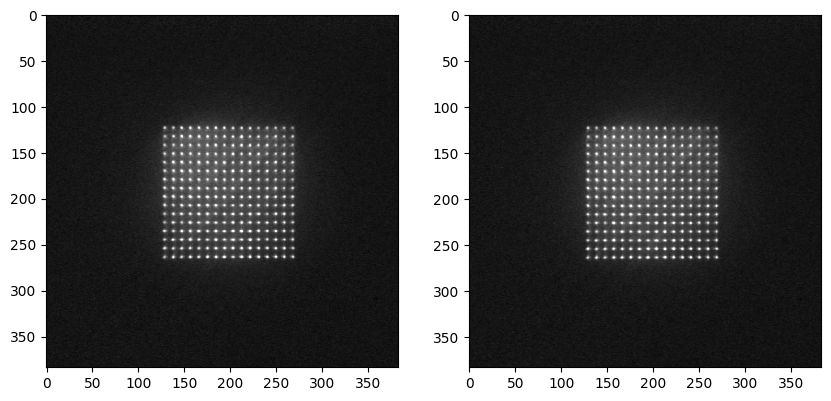

In [26]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
local_cam.setup_acquisition("snap", n_iterations * 2)
local_cam.start_acquisition()
exp.start_motmaster_experiment()

imgs = local_cam.acquire_n_frames(n_iterations * 2)
imgs1 = imgs[::2]
imgs2 = imgs[1::2]
img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
16x16 array detected.


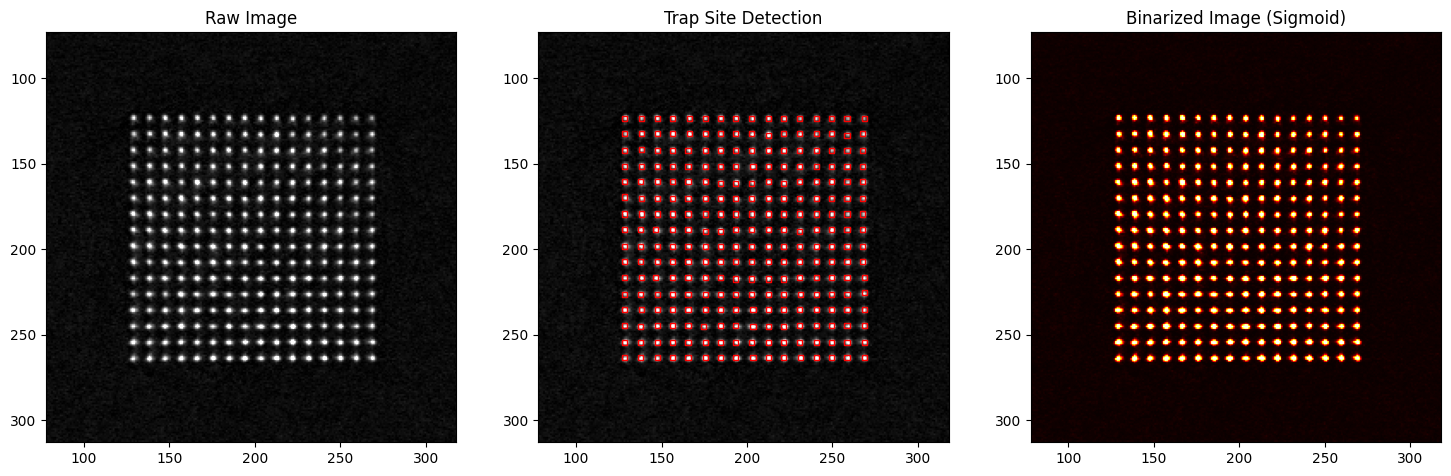

Trap (0, 0) Loading Probability : 55.00 %
Trap (0, 1) Loading Probability : 52.00 %
Trap (0, 2) Loading Probability : 56.00 %
Trap (0, 3) Loading Probability : 54.00 %
Trap (0, 4) Loading Probability : 56.00 %
Trap (0, 5) Loading Probability : 48.00 %
Trap (0, 6) Loading Probability : 49.00 %
Trap (0, 7) Loading Probability : 53.00 %
Trap (0, 8) Loading Probability : 54.00 %
Trap (0, 9) Loading Probability : 54.00 %
Trap (0, 10) Loading Probability : 54.00 %
Trap (0, 11) Loading Probability : 48.00 %
Trap (0, 12) Loading Probability : 54.00 %
Trap (0, 13) Loading Probability : 58.00 %
Trap (0, 14) Loading Probability : 52.00 %
Trap (0, 15) Loading Probability : 55.00 %
Trap (1, 0) Loading Probability : 53.00 %
Trap (1, 1) Loading Probability : 54.00 %
Trap (1, 2) Loading Probability : 61.00 %
Trap (1, 3) Loading Probability : 59.00 %
Trap (1, 4) Loading Probability : 57.00 %
Trap (1, 5) Loading Probability : 52.00 %
Trap (1, 6) Loading Probability : 49.00 %
Trap (1, 7) Loading Probabil

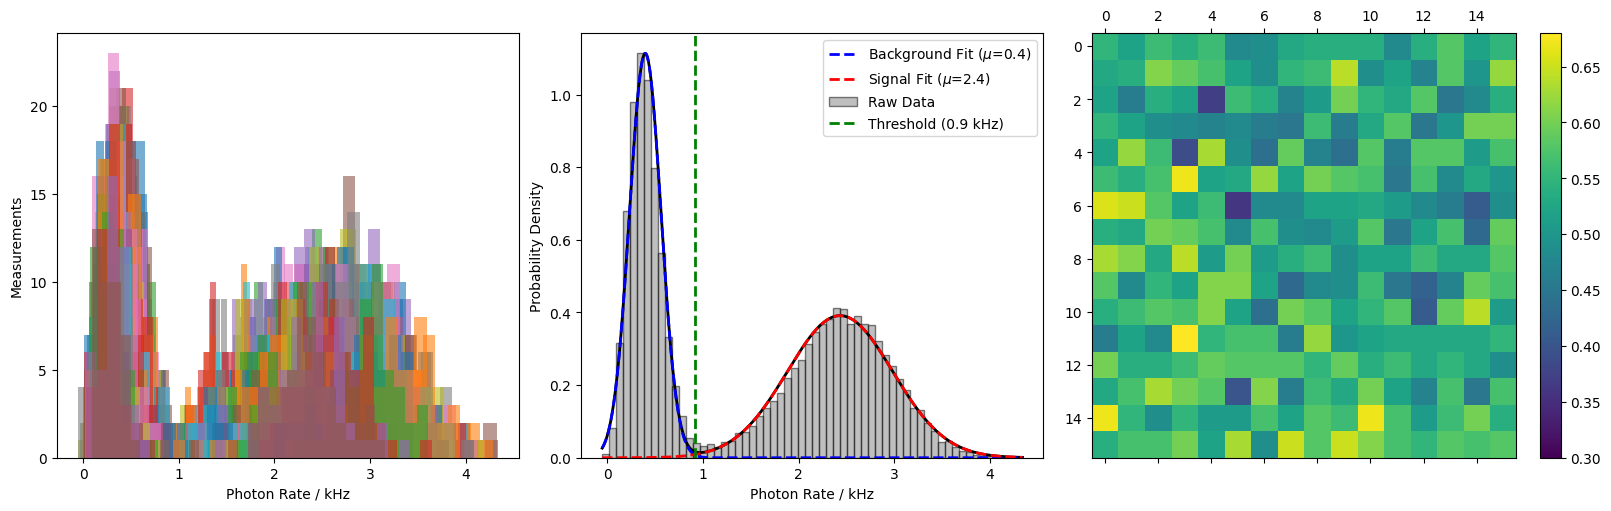

In [27]:
array_shape = [16, 16]
window = 3
feature_size = 10

filtered_img_average = pyt.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions, detection_threshold = pyt.detect_trap_sites(filtered_img_average, array_shape, detection_step=500)
pyt.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)

In [28]:
a = 0.00483372
b = 1828.38
photons = threshold*1000*80e-3
electrons = photons * 0.7
threshold_counts = electrons / a + b
print(threshold_counts)

12448.00120011441


Filling fraction: 53.91%
Probability of obtaining fewer than 100 atoms loaded: 0.000028%
Probability of obtaining more than 100 atoms loaded: 99.999972%


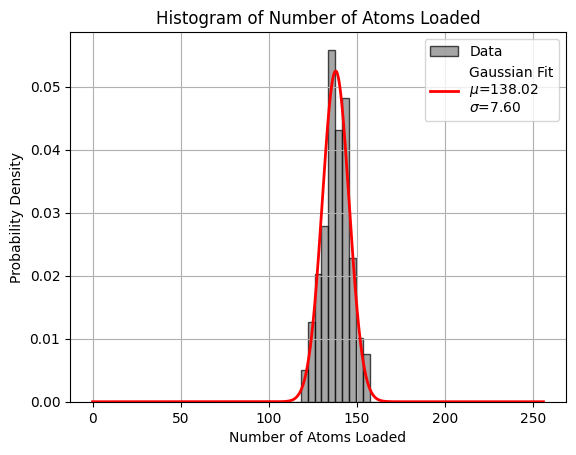

In [29]:
num_atoms_list = []
for pr in photon_rates:
    num_atoms = np.sum(pr > threshold)
    num_atoms_list.append(num_atoms)

# Fit a Gaussian distribution to num_atoms_list, extract the mean, and standard deviation.
mean_num_atoms = np.mean(num_atoms_list)
std_num_atoms = np.std(num_atoms_list)

# Plot a gaussian distribution to the data using the mean and standard deviation.
x = np.linspace(0, 256, 1000)
gaussian = (1 / (std_num_atoms * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean_num_atoms) / std_num_atoms) ** 2)

# In the legend include the mean and standard deviation of the fitted Gaussian distribution.
plt.hist(num_atoms_list, range=(0, 256), bins=65, density=True, alpha=0.7, color='gray', label='Data', edgecolor='black')
plt.plot(x, gaussian, color='red', linewidth=2, label='Gaussian Fit\n$\mu$={:.2f}\n$\sigma$={:.2f}'.format(mean_num_atoms, std_num_atoms))
plt.xlabel('Number of Atoms Loaded')
plt.ylabel('Probability Density')
plt.title('Histogram of Number of Atoms Loaded')
plt.legend()
plt.grid()

# Calculate the probability of obtaining fewer than 100 atoms loaded using the fitted Gaussian distribution.
from scipy.stats import norm

n_at = 10 ** 2
prob_fewer = norm.cdf(n_at, loc=mean_num_atoms, scale=std_num_atoms)

print(f"Filling fraction: {mean_num_atoms / 256:.2%}")
print(f"Probability of obtaining fewer than {n_at} atoms loaded: {prob_fewer * 100:.6f}%")
print(f"Probability of obtaining more than {n_at} atoms loaded: {(1 - prob_fewer) * 100:.6f}%")

## Baseline Survival Probability - 100 ms Rearrangement Delay

- In this case we DO NOT ramp down the power to 50%. We only do that when we are rearranging to a smaller array. Keep the set vva values for the tweezer power at 0.0.
- Imaging for 50 ms. Img cool VCO at 0.911 and VVA at 0.43.

In [30]:
def extract_survival_probability(imgs1, imgs2):
    pr_1, eta_1, thresh_1, fidelity_1 = texp.get_array_loading_statistics(imgs1, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60, show_histogram=False, verbose=False)
    pr_2, eta_2, thresh_2, fidelity_2 = texp.get_array_loading_statistics(imgs2, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60, show_histogram=False, verbose=False)
    survival_fractions = []
    for i in range(pr_1.shape[0]):

        pr_mat_1 = pr_1[i]
        pr_mat_2 = pr_2[i]

        pr_mat_1_binary = (pr_mat_1 > thresh_1).astype(int)
        pr_mat_2_binary = (pr_mat_2 > thresh_2).astype(int)
        survival_matrix = pr_mat_1_binary * pr_mat_2_binary

        init_occupation = pr_mat_1_binary.sum()
        final_occupation = pr_mat_2_binary.sum()
        survival_count = survival_matrix.sum()
        survival_fraction = survival_count / init_occupation if init_occupation > 0 else 0
        survival_fractions.append(survival_fraction)

    survival_probability = np.mean(survival_fractions)
    return survival_probability

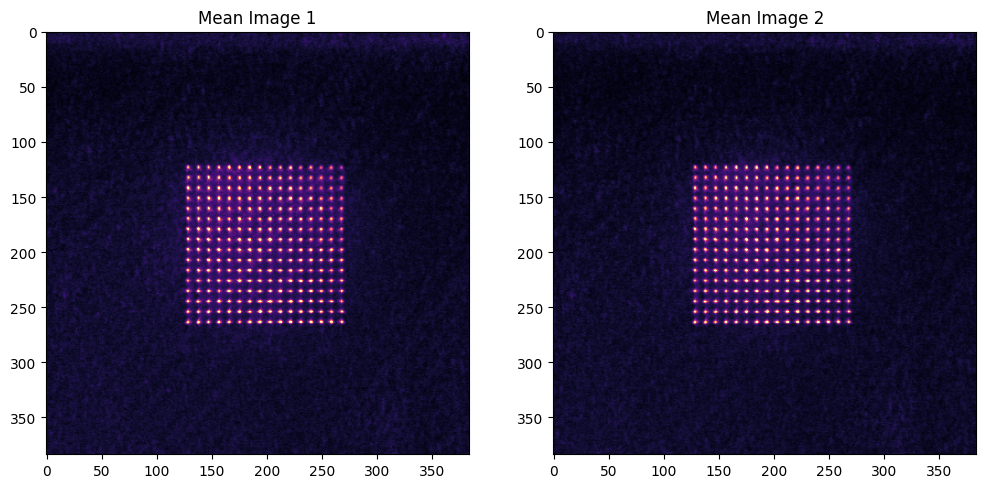

Survival Probability: 93.20%


In [31]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
local_cam.setup_acquisition("snap", n_iterations * 2)
local_cam.start_acquisition()
exp.start_motmaster_experiment({"BackgroundDrop": 0})

imgs = local_cam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
imgs_11 = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
imgs_22 = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
imgs_11_mean = np.mean(imgs_11, axis=0)
imgs_22_mean = np.mean(imgs_22, axis=0)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imgs_11_mean, cmap='magma', vmax=imgs_11_mean.max()*0.6)
plt.title('Mean Image 1')
plt.subplot(1, 2, 2)
plt.imshow(imgs_22_mean, cmap='magma', vmax=imgs_22_mean.max()*0.6)
plt.title('Mean Image 2')
plt.show()

survival_prob = extract_survival_probability(imgs_11, imgs_22)
print(f"Survival Probability: {survival_prob * 100:.2f}%")

---
## Generate Final Array

In [ ]:
W2 = np.ones((10, 10))
spacing_um = 4.5

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W2 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms2 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 4.5 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.30e-05 | Uniformity: 58.11% | Min/Max ratio: 0.113
Iteration 010 | Mean-Squared Error: 1.47e-07 | Uniformity: 87.21% | Min/Max ratio: 0.582
Iteration 020 | Mean-Squared Error: 3.72e-08 | Uniformity: 87.44% | Min/Max ratio: 0.595
Iteration 030 | Mean-Squared Error: 1.02e-08 | Uniformity: 87.75% | Min/Max ratio: 0.622
Iteration 040 | Mean-Squared Error: 4.07e-09 | Uniformity: 87.67% | Min/Max ratio: 0.622
Iteration 050 | Mean-Squared Error: 2.33e-09 | Uniformity: 87.56% | Min/Max ratio: 0.620
Iteration 060 | Mean-Squared Error: 5.10e-09 | Uniformity: 87.52% | Min/Max ratio: 0.623
Iteration 070 | Mean-Squared Error: 4.13e-09 | Uniformity: 87.52% | Min/Max ratio: 0.630
Iteration 080 | Mean-Squared Error: 1.39e-09 | Uniformity: 87.60% | Min/Max ratio: 0.630
Iteration 090 | Mean-Squared Error: 7.23e-10 | Uniformity: 87.63% | Min/Max ratio: 0.629
Itera

---
## Rearrangement Exp

In [ ]:
import asyncio
from pytweezer.communication import RearrangementNode

local_cam.relinquish_camera()
RN = RearrangementNode()

### Exp 1

In [ ]:
await RN.initialise(terms1, terms2, grid_positions, threshold_counts, d0=0.75, fps=1/(1e-6), roi=[X0, Y0, WIDTH, HEIGHT])

# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{"status": "success", "msg": "Rearrangement node initialised."}


{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [ ]:
N_iterations = 1
imgs = []
err_indices = []
occ_extraction_times = []
rearrangement_sequence_calc_times = []
slm_upload_times = []
total_rearrangement_times = []

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(RN.arm_rearrangement())

    sleep(0.1)
    exp.start_motmaster_experiment({"BackgroundDrop": 0})
    img0, img1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs.append([img0, img1])

    occ_extraction_times.append(timings['occupancy_extraction_s'])
    rearrangement_sequence_calc_times.append(timings['rearrangement_sequence_generation_s'])
    slm_upload_times.append(timings['slm_upload_s'])
    total_rearrangement_times.append(timings['total_rearrangement_s'])

print(f"\nAverage occupancy extraction time = {np.mean(occ_extraction_times)*1000:.2f} ms")
print(f"Average rearrangement sequence generation time = {np.mean(rearrangement_sequence_calc_times)*1000:.2f} ms")
print(f"Average SLM upload time = {np.mean(slm_upload_times)*1000:.2f} ms")
print(f"Average total rearrangement time = {np.mean(total_rearrangement_times)*1000:.2f} ms")

Running experiment iteration 1 / 1
ARM command sent...
Images acquired from rearrangement node.

Average occupancy extraction time = 4.00 ms
Average rearrangement sequence generation time = 37.01 ms
Average SLM upload time = 71.72 ms
Average total rearrangement time = 112.73 ms


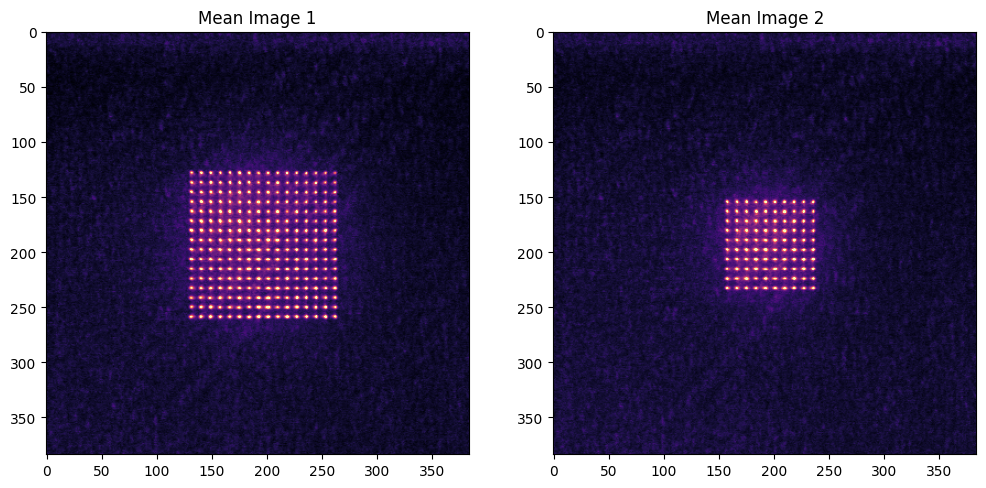

In [ ]:
tot_imgs = np.array(imgs)
imgs1 = tot_imgs[:, 0]
imgs2 = tot_imgs[:, 1]
imgs_11 = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
imgs_22 = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(np.mean(imgs_11, axis=0), cmap='magma', vmax=np.mean(imgs_11, axis=0).max()*0.6)
plt.title('Mean Image 1')
plt.subplot(1, 2, 2)
plt.imshow(np.mean(imgs_22, axis=0), cmap='magma', vmax=np.mean(imgs_22, axis=0).max()*0.6)
plt.title('Mean Image 2')
plt.show()

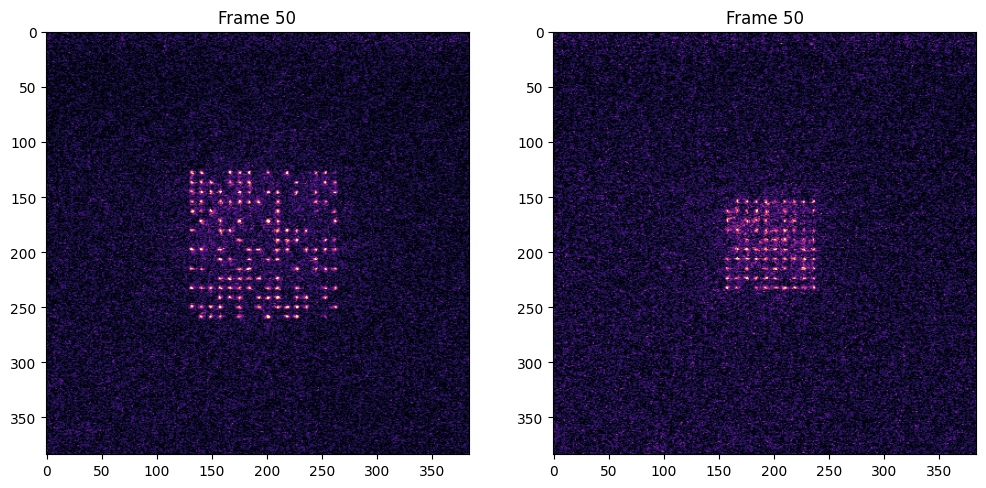

In [ ]:
n = 50
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imgs_11[n], cmap='magma', vmax=imgs_11[n].max()*0.6)
plt.title(f'Frame {n}')
plt.subplot(1, 2, 2)
plt.imshow(imgs_22[n], cmap='magma', vmax=imgs_22[n].max()*0.6)
plt.title(f'Frame {n}')
plt.show()

#### Initial Array Statistics

Looking for trap sites...
16x16 array detected.


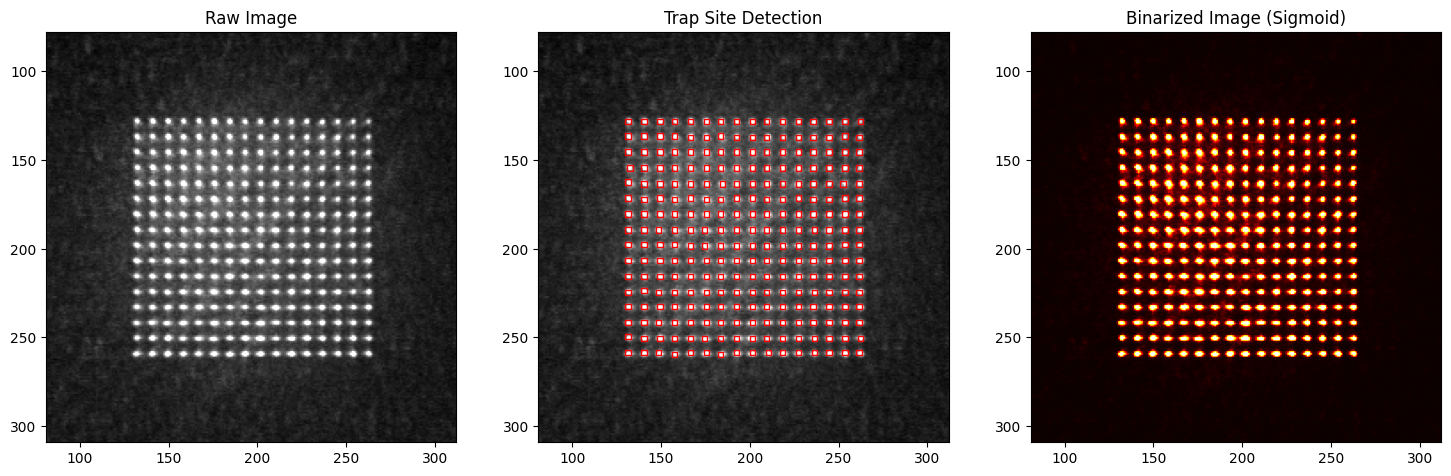

Trap (0, 0) Loading Probability : 54.00 %
Trap (0, 1) Loading Probability : 61.00 %
Trap (0, 2) Loading Probability : 57.00 %
Trap (0, 3) Loading Probability : 47.00 %
Trap (0, 4) Loading Probability : 51.00 %
Trap (0, 5) Loading Probability : 62.00 %
Trap (0, 6) Loading Probability : 53.00 %
Trap (0, 7) Loading Probability : 41.00 %
Trap (0, 8) Loading Probability : 53.00 %
Trap (0, 9) Loading Probability : 50.00 %
Trap (0, 10) Loading Probability : 54.00 %
Trap (0, 11) Loading Probability : 59.00 %
Trap (0, 12) Loading Probability : 54.00 %
Trap (0, 13) Loading Probability : 53.00 %
Trap (0, 14) Loading Probability : 48.00 %
Trap (0, 15) Loading Probability : 47.00 %
Trap (1, 0) Loading Probability : 51.00 %
Trap (1, 1) Loading Probability : 50.00 %
Trap (1, 2) Loading Probability : 60.00 %
Trap (1, 3) Loading Probability : 55.00 %
Trap (1, 4) Loading Probability : 57.00 %
Trap (1, 5) Loading Probability : 56.00 %
Trap (1, 6) Loading Probability : 48.00 %
Trap (1, 7) Loading Probabil

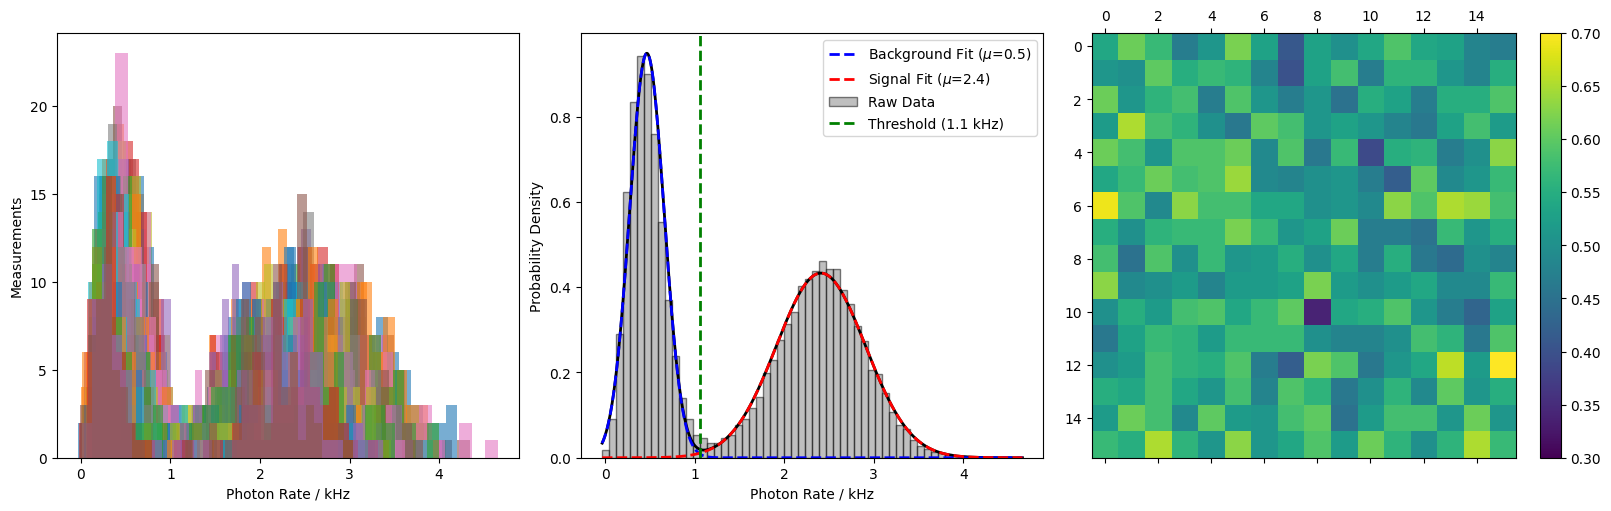

In [ ]:
array_shape = [16, 16]
window = 3
feature_size = 10

grid_positions11, detection_threshold = pyt.detect_trap_sites(np.mean(imgs_11, axis=0), array_shape, detection_step=500)
pyt.visualize_results(np.mean(imgs_11, axis=0), grid_positions11, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_11, grid_positions11, array_shape, threshold_detection=True, window_size=window, binning=60)

#### Final Array Statistics

Looking for trap sites...
10x10 array detected.


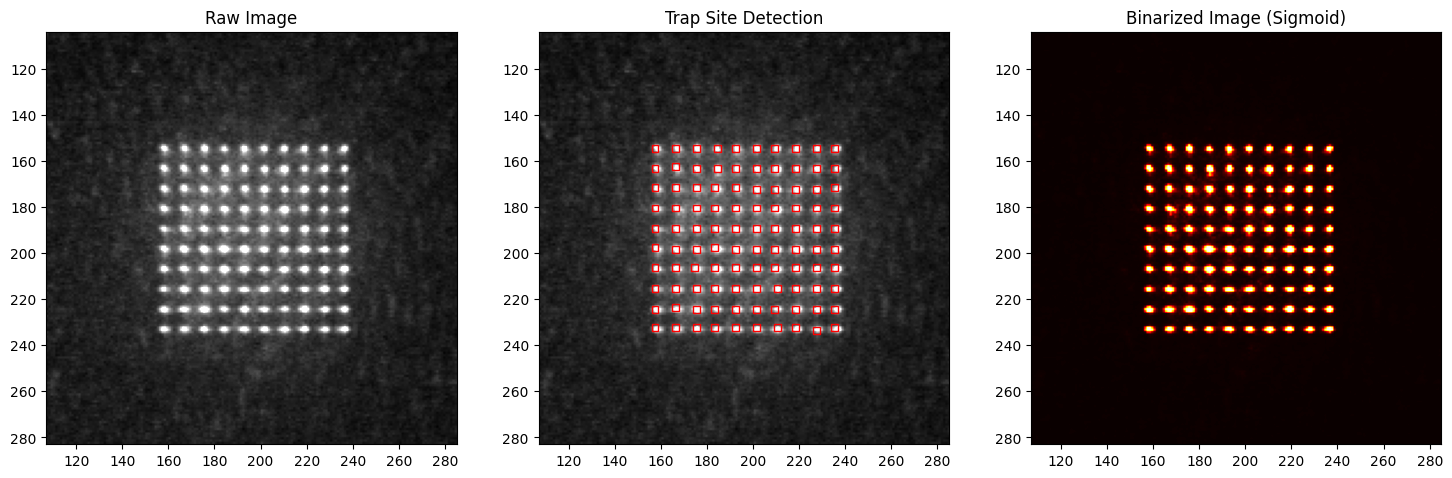

Trap (0, 0) Loading Probability : 74.00 %
Trap (0, 1) Loading Probability : 77.00 %
Trap (0, 2) Loading Probability : 82.00 %
Trap (0, 3) Loading Probability : 68.00 %
Trap (0, 4) Loading Probability : 79.00 %
Trap (0, 5) Loading Probability : 81.00 %
Trap (0, 6) Loading Probability : 84.00 %
Trap (0, 7) Loading Probability : 83.00 %
Trap (0, 8) Loading Probability : 74.00 %
Trap (0, 9) Loading Probability : 78.00 %
Trap (1, 0) Loading Probability : 71.00 %
Trap (1, 1) Loading Probability : 74.00 %
Trap (1, 2) Loading Probability : 80.00 %
Trap (1, 3) Loading Probability : 80.00 %
Trap (1, 4) Loading Probability : 84.00 %
Trap (1, 5) Loading Probability : 82.00 %
Trap (1, 6) Loading Probability : 86.00 %
Trap (1, 7) Loading Probability : 80.00 %
Trap (1, 8) Loading Probability : 82.00 %
Trap (1, 9) Loading Probability : 76.00 %
Trap (2, 0) Loading Probability : 72.00 %
Trap (2, 1) Loading Probability : 76.00 %
Trap (2, 2) Loading Probability : 73.00 %
Trap (2, 3) Loading Probability : 

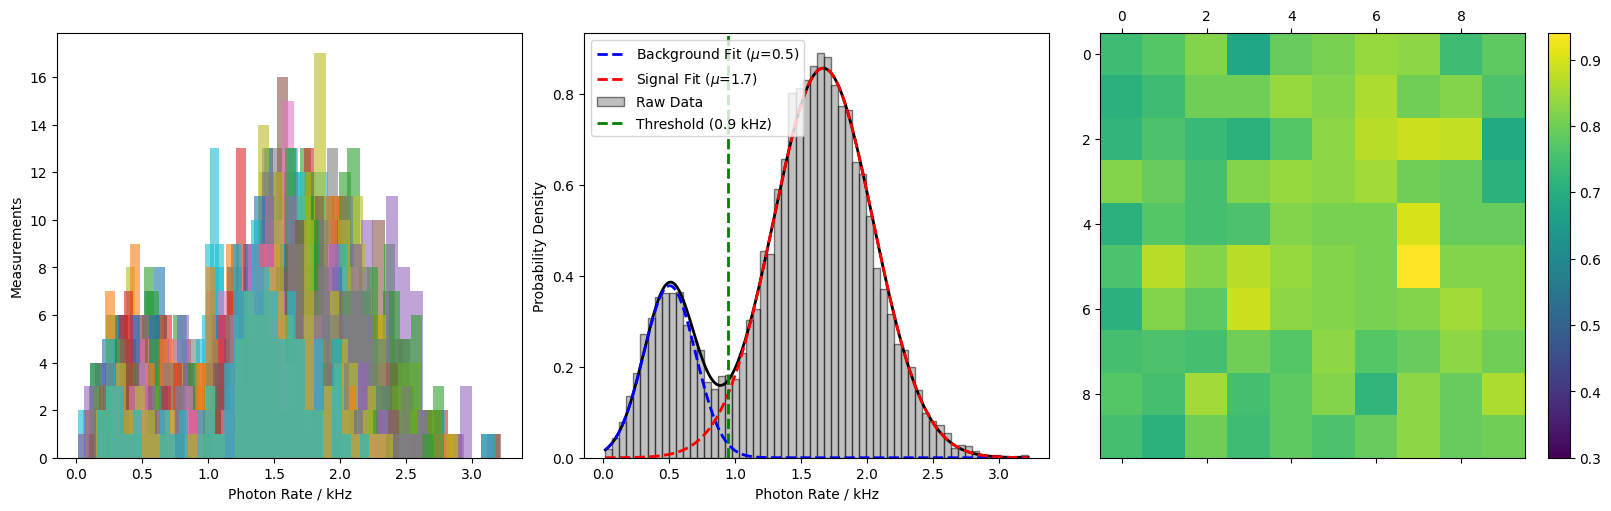

In [ ]:
array_shape = [10, 10]
window = 3
feature_size = 10

grid_positions22, detection_threshold = pyt.detect_trap_sites(np.mean(imgs_22, axis=0), array_shape, detection_step=500)
pyt.visualize_results(np.mean(imgs_22, axis=0), grid_positions22, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_22, grid_positions22, array_shape, threshold_detection=True, window_size=window, binning=60)